# HyFIN-Net — Ablation Study
Systematically ablates each module to measure its individual contribution.

**Variants (11 total)**
- **Group A** (primary): Full model, w/o IGM, w/o HM, w/o MF, w/o CrossModalAttn, w/o CBFC Loss
- **Group B** (sub-components): w/o SpeakerEmb, w/o PosEnc, w/o InputLN, IGM w/o ImplicitEdges, IGM SingleBranch

Results saved incrementally to `outputs/ablation/` after each variant.

In [1]:
import subprocess, sys, importlib
def _try(mod):
    try:
        importlib.import_module(mod); return True
    except Exception:
        return False
if not _try('torch_scatter') or not _try('torch_sparse'):
    import torch as _t
    tv = _t.__version__.split('+')[0]
    cu = _t.version.cuda.replace('.', '') if _t.version.cuda else 'cpu'
    url = f'https://data.pyg.org/whl/torch-{tv}+cu{cu}.html'
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '--no-index',
                    'torch_scatter', 'torch_sparse', '-f', url], check=False)
    if not _try('torch_geometric'):
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'torch_geometric'], check=False)
import torch, torch_geometric
print('torch', torch.__version__, '| cuda', torch.version.cuda, '| pyg', torch_geometric.__version__)
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')
import os
IS_KAGGLE = os.path.exists('/kaggle/working')
print('Platform: Kaggle' if IS_KAGGLE else 'Platform: local')

torch 2.11.0+cu128 | cuda 12.8 | pyg 2.7.0
GPU: NVIDIA GeForce RTX 3060
Platform: local


In [2]:
import os, pickle, math, random, time, copy, json
from pathlib import Path
from itertools import permutations
from dataclasses import dataclass, field
from typing import Optional
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch_geometric.nn import GraphConv, TransformerConv
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax as pyg_softmax, degree
from torch_scatter import scatter_add
from sklearn.metrics import f1_score, accuracy_score, classification_report

SEED = 2024
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)

# ── Ablation-study settings ───────────────────────────────────────────────────
ABLATION_EPOCHS = 30          # use 60 for full-fidelity; 30 for fast sweep
ABLATION_SEED   = 42

device = cuda


In [3]:
_LOCAL_DATA_ROOT = os.environ.get(
    'GRAPHSMILE_DATA',
    str(Path('/mnt/Work/ML/Thesis/WACV/data/GraphSmile_PreProcessed')))
_LOCAL_SAVE_DIR = os.environ.get('HYFIN_SAVE_DIR', './outputs')

class Cfg:
    dataset      = 'iemocap'
    data_root    = ('/kaggle/input/datasets/gilbertstrange/graphsmile-preprocessed/GraphSmile_PreProcessed'
                    if IS_KAGGLE else _LOCAL_DATA_ROOT)
    save_dir     = '/kaggle/working' if IS_KAGGLE else _LOCAL_SAVE_DIR
    @property
    def meld_path(self):    return f'{self.data_root}/meld_multi_features.pkl'
    @property
    def iemocap_path(self): return f'{self.data_root}/iemocap_multi_features.pkl'
    batch_size_d = {'iemocap': 16, 'meld': 32}
    epochs       = 60      # full training epochs (not used for ablation)
    lr           = 4e-4
    weight_decay = 1e-4
    grad_clip    = 1.0
    warmup_epochs = 1
    label_smoothing = 0.1
    hidden       = 256
    n_speakers   = {'iemocap': 2, 'meld': 9}
    n_classes    = {'iemocap': 6, 'meld': 7}
    igm_branches = {
        'iemocap': [(5, 3), (3, 2)],
        'meld':    [(7, 4), (5, 3)],
    }
    igm_layers   = 2
    igm_heads    = 4
    hm_layers    = {'iemocap': 2, 'meld': 4}
    mf_layers    = {'iemocap': 4, 'meld': 3}
    ca_heads     = 4
    dropout      = {'iemocap': 0.5, 'meld': 0.5}
    beta_cb      = 0.999
    cbfc_mu      = 0.1
    cbfc_gamma   = 2.0
    cbfc_temp    = 0.5
    dualcl_lam   = 0.0
    dualcl_tau   = 0.5
    dualcl_drop  = 0.1
    max_hm_nodes = 50_000
    max_hm_edges = 50_000
    val_frac     = 0.1
    log_every    = 999999   # suppress step-level logs during ablation sweep
    @property
    def batch_size(self): return self.batch_size_d[self.dataset]

cfg = Cfg()
os.makedirs(cfg.save_dir, exist_ok=True)
print(f'data_root: {cfg.data_root}')
print(f'save_dir : {cfg.save_dir}')

data_root: /mnt/Work/ML/Thesis/WACV/data/GraphSmile_PreProcessed
save_dir : ./outputs


In [4]:
ABL_OUT  = Path(cfg.save_dir) / 'ablation'
PLOT_DIR = ABL_OUT / 'plots'
CKPT_DIR = ABL_OUT / 'checkpoints'
RESULTS_FILE = ABL_OUT / 'ablation_results.json'

for d in [ABL_OUT, PLOT_DIR, CKPT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def _load_results():
    if RESULTS_FILE.exists():
        with open(RESULTS_FILE) as f:
            return json.load(f)
    return {}

def _save_results(results):
    with open(RESULTS_FILE, 'w') as f:
        json.dump(results, f, indent=2)

print('Ablation output dir:', ABL_OUT)

Ablation output dir: outputs/ablation


In [5]:
def _load_pickle(path):
    with open(path, 'rb') as f:
        try:
            return pickle.load(f, encoding='latin1')
        except TypeError:
            f.seek(0); return pickle.load(f)

def parse_graphsmile_pickle(path, dataset):
    obj = _load_pickle(path)
    assert isinstance(obj, (tuple, list)), f'unexpected pickle type {type(obj)}'
    n = len(obj)
    if n == 9:
        (videoIDs, videoSpeakers, videoLabels,
         videoText, videoAudio, videoVisual, videoSentence,
         trainVid, testVid) = obj
        text_dict = videoText
    elif n in (12,):
        (videoIDs, videoSpeakers, videoLabels,
         vT0, vT1, vT2, vT3,
         videoAudio, videoVisual, videoSentence,
         trainVid, testVid) = obj
        text_dict = {vid: (np.asarray(vT0[vid], dtype=np.float32)
                          + np.asarray(vT1[vid], dtype=np.float32)
                          + np.asarray(vT2[vid], dtype=np.float32)
                          + np.asarray(vT3[vid], dtype=np.float32)) / 4.0
                     for vid in vT0.keys()}
    elif n in (13, 14):
        (videoIDs, videoSpeakers, videoLabels, videoSentiments,
         vT0, vT1, vT2, vT3,
         videoAudio, videoVisual, videoSentence,
         trainVid, testVid, *rest) = obj
        text_dict = {vid: (np.asarray(vT0[vid], dtype=np.float32)
                          + np.asarray(vT1[vid], dtype=np.float32)
                          + np.asarray(vT2[vid], dtype=np.float32)
                          + np.asarray(vT3[vid], dtype=np.float32)) / 4.0
                     for vid in vT0.keys()}
    else:
        raise ValueError(f'unsupported pickle layout: {n} fields')

    sample_vid = next(iter(text_dict))
    Dt = int(np.asarray(text_dict[sample_vid]).shape[-1])
    Da = int(np.asarray(videoAudio[sample_vid]).shape[-1])
    Dv = int(np.asarray(videoVisual[sample_vid]).shape[-1])
    print(f'  layout={n} fields  dims t/a/v = {Dt}/{Da}/{Dv}  train={len(trainVid)}, test={len(testVid)}')
    return dict(text=text_dict, audio=videoAudio, visual=videoVisual,
                labels=videoLabels, speakers=videoSpeakers, sentences=videoSentence,
                trainVid=list(trainVid), testVid=list(testVid))

def _speaker_to_idx(spk, dataset):
    if dataset == 'iemocap':
        out = []
        for s in spk:
            if isinstance(s, (str, bytes)):
                ss = s.decode() if isinstance(s, bytes) else s
                out.append({'M': 0, 'F': 1}.get(ss, 0))
            else:
                out.append(int(s))
        return out
    arr = np.asarray(spk)
    if arr.ndim == 2:
        return arr.argmax(-1).tolist()
    return arr.astype(int).tolist()

class MERCDataset(Dataset):
    def __init__(self, raw, vids, dataset):
        self.raw = raw; self.vids = vids; self.dataset = dataset
    def __len__(self): return len(self.vids)
    def __getitem__(self, idx):
        vid = self.vids[idx]
        t = np.asarray(self.raw['text'][vid],   dtype=np.float32)
        a = np.asarray(self.raw['audio'][vid],  dtype=np.float32)
        v = np.asarray(self.raw['visual'][vid], dtype=np.float32)
        y = np.asarray(self.raw['labels'][vid], dtype=np.int64)
        spk = _speaker_to_idx(self.raw['speakers'][vid], self.dataset)
        return {
            'text': torch.from_numpy(t), 'audio': torch.from_numpy(a),
            'visual': torch.from_numpy(v), 'label': torch.from_numpy(y),
            'speaker': torch.tensor(spk, dtype=torch.long),
            'length': int(t.shape[0]),
        }

def pad_collate(batch):
    B = len(batch)
    L = max(s['length'] for s in batch)
    Dt = batch[0]['text'].shape[-1]
    Da = batch[0]['audio'].shape[-1]
    Dv = batch[0]['visual'].shape[-1]
    text   = torch.zeros(B, L, Dt)
    audio  = torch.zeros(B, L, Da)
    visual = torch.zeros(B, L, Dv)
    spk    = torch.zeros(B, L, dtype=torch.long)
    lens   = torch.zeros(B, dtype=torch.long)
    labels = []
    for i, s in enumerate(batch):
        n = s['length']
        text[i, :n]   = s['text']
        audio[i, :n]  = s['audio']
        visual[i, :n] = s['visual']
        spk[i, :n]    = s['speaker']
        lens[i]       = n
        labels.append(s['label'])
    return {'text': text, 'audio': audio, 'visual': visual,
            'speaker': spk, 'lengths': lens, 'labels': torch.cat(labels)}

# Load data
path = cfg.meld_path if cfg.dataset == 'meld' else cfg.iemocap_path
print(f'loading {path}')
raw = parse_graphsmile_pickle(path, dataset=cfg.dataset)
print('train vids:', len(raw['trainVid']), 'test vids:', len(raw['testVid']))

probe_dims = []
for vid in list(raw['trainVid'])[:5]:
    t = np.asarray(raw['text'][vid]); a = np.asarray(raw['audio'][vid]); v = np.asarray(raw['visual'][vid])
    probe_dims.append((t.shape[-1], a.shape[-1], v.shape[-1]))
assert len(set(probe_dims)) == 1
D_T, D_A, D_V = probe_dims[0]
print(f'feature dims t/a/v = {D_T}/{D_A}/{D_V}')

# Split
train_all = list(raw['trainVid'])
rng = random.Random(SEED); rng.shuffle(train_all)
n_val = max(1, int(len(train_all) * cfg.val_frac))
val_vids   = train_all[:n_val]
train_vids = train_all[n_val:]
test_vids  = list(raw['testVid'])

num_workers = 2 if IS_KAGGLE else min(4, os.cpu_count() or 1)
train_set  = MERCDataset(raw, train_vids, cfg.dataset)
val_set    = MERCDataset(raw, val_vids,   cfg.dataset)
test_set   = MERCDataset(raw, test_vids,  cfg.dataset)
train_loader = DataLoader(train_set, batch_size=cfg.batch_size, shuffle=True,
                          collate_fn=pad_collate, num_workers=num_workers, pin_memory=IS_KAGGLE)
val_loader   = DataLoader(val_set,   batch_size=cfg.batch_size, shuffle=False,
                          collate_fn=pad_collate, num_workers=num_workers, pin_memory=IS_KAGGLE)
test_loader  = DataLoader(test_set,  batch_size=cfg.batch_size, shuffle=False,
                          collate_fn=pad_collate, num_workers=num_workers, pin_memory=IS_KAGGLE)
print(f'split: train={len(train_set)}  val={len(val_set)}  test={len(test_set)}')

class_counts = np.zeros(cfg.n_classes[cfg.dataset], dtype=np.int64)
for vid in train_vids:
    for y in raw['labels'][vid]:
        class_counts[int(y)] += 1
print('train class counts:', class_counts.tolist())

loading /mnt/Work/ML/Thesis/WACV/data/GraphSmile_PreProcessed/iemocap_multi_features.pkl
  layout=12 fields  dims t/a/v = 1024/1582/342  train=120, test=31
train vids: 120 test vids: 31
feature dims t/a/v = 1024/1582/342
split: train=108  val=12  test=31
train class counts: [474, 763, 1200, 814, 711, 1267]


## Original Model Classes (verbatim from arch21.ipynb)

In [6]:
# ── Block A: Unimodal Encoder ─────────────────────────────────────────────────

class InputLN(nn.Module):
    """Masked per-dialogue LayerNorm over each dialogue's TRUE (unpadded) (n, D) block."""
    def __init__(self, eps=1e-5):
        super().__init__()
        self.eps = eps
    def forward(self, x, lengths):
        B, L, D = x.shape
        if L == 0:
            return x
        valid = (torch.arange(L, device=x.device)[None, :] < lengths[:, None]).unsqueeze(-1)
        vf = valid.to(x.dtype)
        cnt = (vf.sum(dim=(1, 2), keepdim=True) * D).clamp(min=1.0)
        mean = (x * vf).sum(dim=(1, 2), keepdim=True) / cnt
        var = (((x - mean) ** 2) * vf).sum(dim=(1, 2), keepdim=True) / cnt
        out = (x - mean) / torch.sqrt(var + self.eps)
        return out * vf

class PositionalEncoding(nn.Module):
    def __init__(self, d, max_len=200):
        super().__init__()
        pe = torch.zeros(max_len, d)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d, 2).float() * (-math.log(10000.0) / d))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class UnimodalEncoder(nn.Module):
    def __init__(self, d_t, d_a, d_v, d_h, n_speakers, dropout=0.5):
        super().__init__()
        self.in_ln_t = InputLN()
        self.in_ln_a = InputLN()
        self.in_ln_v = InputLN()
        self.t_proj = nn.Linear(d_t, d_h)
        self.pe     = PositionalEncoding(d_h)
        self.t_enc  = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_h, nhead=4, dim_feedforward=d_h,
                                       dropout=dropout, activation='gelu', batch_first=True),
            num_layers=1)
        self.a_proj = nn.Sequential(nn.Linear(d_a, d_h), nn.ReLU(), nn.Dropout(dropout))
        self.v_proj = nn.Sequential(nn.Linear(d_v, d_h), nn.ReLU(), nn.Dropout(dropout))
        self.spk    = nn.Embedding(n_speakers, d_h)
    def forward(self, text, audio, visual, spk, lengths):
        B, L, _ = text.shape
        mask = torch.arange(L, device=text.device)[None] >= lengths[:, None]
        text   = self.in_ln_t(text,   lengths)
        audio  = self.in_ln_a(audio,  lengths)
        visual = self.in_ln_v(visual, lengths)
        ht = self.t_enc(self.pe(self.t_proj(text)), src_key_padding_mask=mask)
        ha = self.a_proj(audio)
        hv = self.v_proj(visual)
        s = self.spk(spk)
        return ht + s, ha + s, hv + s, mask

# ── Graph helpers ─────────────────────────────────────────────────────────────

def flatten_batch(ht, ha, hv, lengths):
    feats, offsets = [], []; cur = 0
    for b, n in enumerate(lengths.tolist()):
        feats.append(torch.cat([ht[b, :n], ha[b, :n], hv[b, :n]], dim=0))
        offsets.append(cur); cur += 3 * n
    return torch.cat(feats, dim=0), offsets

def unflatten_batch(flat, lengths, offsets):
    B = len(lengths); L = int(lengths.max().item()); H = flat.shape[-1]
    ht = flat.new_zeros(B, L, H); ha = flat.new_zeros(B, L, H); hv = flat.new_zeros(B, L, H)
    for b, n in enumerate(lengths.tolist()):
        o = offsets[b]
        ht[b, :n] = flat[o:o+n]; ha[b, :n] = flat[o+n:o+2*n]; hv[b, :n] = flat[o+2*n:o+3*n]
    return ht, ha, hv

def angular_weight(x, edge_index):
    src, dst = edge_index
    xs = F.normalize(x[src], dim=-1); xd = F.normalize(x[dst], dim=-1)
    cos = (xs * xd).sum(-1).clamp(-1 + 1e-6, 1 - 1e-6)
    return 1.0 - torch.arccos(cos) / math.pi

# ── Block B-IGM: Inception Graph Module ──────────────────────────────────────

class ImplicitEdgeDetector(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.W = nn.Linear(2 * d, 1, bias=False)
        self.act = nn.LeakyReLU(0.2)
    def extra_edges(self, feats_per_modality, n):
        if n < 2: return None, None
        f = feats_per_modality
        fi = f.unsqueeze(1).expand(n, n, -1)
        fj = f.unsqueeze(0).expand(n, n, -1)
        s = self.act(self.W(torch.cat([fi, fj], dim=-1)).squeeze(-1))
        causal = torch.tril(torch.ones(n, n, device=f.device, dtype=torch.bool))
        s = s.masked_fill(~causal, -1e9)
        a = F.softmax(s, dim=-1)
        keep = (a > (1.0 / n)) & causal
        idx = keep.nonzero(as_tuple=False)
        if idx.numel() == 0: return None, None
        return idx[:, 0], idx[:, 1]

def build_igm_graph(lengths, offsets, ht, ha, hv, p_window, f_window, implicit=None, device='cpu'):
    src, dst = [], []; feats_for_implicit = (ht, ha, hv)
    for b, n in enumerate(lengths.tolist()):
        o = offsets[b]
        t0, a0, v0 = o, o + n, o + 2 * n
        idx_t = torch.arange(n, device=device) + t0
        idx_a = torch.arange(n, device=device) + a0
        idx_v = torch.arange(n, device=device) + v0
        for x, y in [(idx_t, idx_a), (idx_t, idx_v), (idx_a, idx_v)]:
            src.append(x); dst.append(y); src.append(y); dst.append(x)
        for idx in (idx_t, idx_a, idx_v):
            i_grid = torch.arange(n, device=device)
            for shift in range(1, p_window + 1):
                m = i_grid >= shift
                if m.any():
                    src.append(idx[m]); dst.append(idx[m] - shift)
                    src.append(idx[m] - shift); dst.append(idx[m])
            for shift in range(1, f_window + 1):
                m = (i_grid + shift) < n
                if m.any():
                    src.append(idx[m]); dst.append(idx[m] + shift)
                    src.append(idx[m] + shift); dst.append(idx[m])
        if implicit is not None:
            for mod_idx, base in enumerate([t0, a0, v0]):
                mod_feats = feats_for_implicit[mod_idx][b, :n]
                u, w = implicit.extra_edges(mod_feats, n)
                if u is not None:
                    u = u + base; w = w + base
                    src.append(u); dst.append(w); src.append(w); dst.append(u)
    if len(src) == 0:
        return torch.zeros(2, 0, dtype=torch.long, device=device)
    src = torch.cat(src, dim=0); dst = torch.cat(dst, dim=0)
    return torch.stack([src, dst], dim=0)

class IGMBranch(nn.Module):
    def __init__(self, d, n_layers, heads=4, dropout=0.1):
        super().__init__()
        assert d % heads == 0
        d_head = d // heads
        self.convs = nn.ModuleList([
            TransformerConv(in_channels=d, out_channels=d_head, heads=heads,
                            concat=True, beta=True, dropout=dropout, edge_dim=1)
            for _ in range(n_layers)])
        self.norms = nn.ModuleList([nn.LayerNorm(d) for _ in range(n_layers)])
    def forward(self, x, edge_index, edge_weight=None):
        edge_attr = None if edge_weight is None else edge_weight.unsqueeze(-1)
        h = x
        for conv, ln in zip(self.convs, self.norms):
            h = ln(F.relu(conv(h, edge_index, edge_attr)) + h)
        return h

class InceptionGraphModule(nn.Module):
    def __init__(self, d, windows, n_layers, heads=4, dropout=0.1):
        super().__init__()
        self.windows = windows
        self.branches = nn.ModuleList([IGMBranch(d, n_layers, heads=heads, dropout=dropout)
                                       for _ in windows])
        self.implicit = ImplicitEdgeDetector(d)
    def forward(self, flat, lengths, offsets, ht, ha, hv):
        outs = []
        for (p, f), branch in zip(self.windows, self.branches):
            edge_index = build_igm_graph(lengths, offsets, ht, ha, hv,
                                         p, f, implicit=self.implicit, device=flat.device)
            ew = angular_weight(flat, edge_index)
            outs.append(branch(flat, edge_index, ew))
        return torch.stack(outs, dim=0).mean(dim=0)

# ── Block B-HM: Hypergraph Module ────────────────────────────────────────────

class HypergraphConvM3(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.lin = nn.Linear(d_in, d_out, bias=False)
        self.bias = nn.Parameter(torch.zeros(d_out))
    def forward(self, x, hyperedge_index, hyperedge_weight=None, ew_weight=None):
        N = x.size(0)
        if hyperedge_index.numel() == 0:
            return F.leaky_relu(self.lin(x) + self.bias)
        node_idx, edge_idx = hyperedge_index[0], hyperedge_index[1]
        E = int(edge_idx.max().item()) + 1
        if hyperedge_weight is None:
            hyperedge_weight = x.new_ones(E)
        D = scatter_add(hyperedge_weight[edge_idx], node_idx, dim=0, dim_size=N)
        D = 1.0 / D; D[D == float('inf')] = 0
        if ew_weight is None:
            B_ = scatter_add(x.new_ones(hyperedge_index.size(1)), edge_idx, dim=0, dim_size=E)
        else:
            B_ = scatter_add(ew_weight[node_idx], edge_idx, dim=0, dim_size=E)
        B_ = 1.0 / B_; B_[B_ == float('inf')] = 0
        h = self.lin(x)
        msg_n2e = h[node_idx] * B_[edge_idx].unsqueeze(-1)
        out_e   = scatter_add(msg_n2e, edge_idx, dim=0, dim_size=E)
        msg_e2n = out_e[edge_idx] * D[node_idx].unsqueeze(-1)
        out_n   = scatter_add(msg_e2n, node_idx, dim=0, dim_size=N)
        return F.leaky_relu(out_n + self.bias)

def build_hyperedge_index(lengths, offsets, device):
    nodes, edges = [], []; edge_count = 0
    for b, n in enumerate(lengths.tolist()):
        o = offsets[b]; t0, a0, v0 = o, o + n, o + 2 * n
        for base in (t0, a0, v0):
            for k in range(n):
                nodes.append(base + k); edges.append(edge_count)
            edge_count += 1
        for k in range(n):
            nodes.extend([t0 + k, a0 + k, v0 + k])
            edges.extend([edge_count] * 3); edge_count += 1
    if len(nodes) == 0:
        return torch.zeros(2, 0, dtype=torch.long, device=device)
    return torch.tensor([nodes, edges], dtype=torch.long, device=device)

class HyperGraphModule(nn.Module):
    def __init__(self, d, n_layers, max_nodes=50_000, max_edges=50_000):
        super().__init__()
        self.convs = nn.ModuleList([HypergraphConvM3(d, d) for _ in range(n_layers)])
        self.hyperedge_weight = nn.Parameter(torch.ones(max_edges))
        self.ew_weight        = nn.Parameter(torch.ones(max_nodes))
    def forward(self, flat, lengths, offsets):
        hi = build_hyperedge_index(lengths, offsets, flat.device)
        E = int(hi[1].max().item()) + 1; N = flat.size(0)
        w = self.hyperedge_weight[:E]; ew = self.ew_weight[:N]
        h = flat
        for conv in self.convs:
            h = conv(h, hi, w, ew)
        return h

# ── Block C: Multi-Frequency Module ──────────────────────────────────────────

class HighFreqConv(MessagePassing):
    def __init__(self, d):
        super().__init__(aggr='add')
        self.gate = nn.Linear(2 * d, 1)
    def forward(self, x, edge_index):
        return self.propagate(edge_index, size=(x.size(0), x.size(0)), x=x)
    def message(self, x_i, x_j, edge_index, size):
        row, col = edge_index
        deg_ = degree(row, size[0], dtype=x_j.dtype)
        d_inv = deg_.pow(-0.5)
        norm  = d_inv[row] * d_inv[col]
        a_g   = torch.tanh(self.gate(torch.cat([x_i, x_j], dim=1)))
        return norm.view(-1, 1) * x_j * a_g

def build_mf_edges(lengths, offsets, device):
    src, dst = [], []
    for b, n in enumerate(lengths.tolist()):
        o = offsets[b]; t0, a0, v0 = o, o + n, o + 2 * n
        for base in (t0, a0, v0):
            for pair in permutations(range(n), 2):
                src.append(base + pair[0]); dst.append(base + pair[1])
        for k in range(n):
            ids = [t0 + k, a0 + k, v0 + k]
            for x, y in permutations(ids, 2):
                src.append(x); dst.append(y)
    if len(src) == 0:
        return torch.zeros(2, 0, dtype=torch.long, device=device)
    return torch.tensor([src, dst], dtype=torch.long, device=device)

class MultiFrequencyModule(nn.Module):
    def __init__(self, d, k_layers):
        super().__init__()
        self.convs = nn.ModuleList([HighFreqConv(d) for _ in range(k_layers)])
    def forward(self, flat, lengths, offsets):
        ei = build_mf_edges(lengths, offsets, flat.device)
        h = flat
        for c in self.convs:
            h = h + c(h, ei)
        return h

# ── Block E: Cross-Modal Attention + Block F: Classifier ─────────────────────

class CrossModalAttn(nn.Module):
    def __init__(self, d_in, d_h, heads=4, dropout=0.3):
        super().__init__()
        self.proj_t = nn.Linear(d_in, d_h)
        self.proj_a = nn.Linear(d_in, d_h)
        self.proj_v = nn.Linear(d_in, d_h)
        self.va = nn.MultiheadAttention(d_h, heads, dropout=dropout, batch_first=True)
        self.aa = nn.MultiheadAttention(d_h, heads, dropout=dropout, batch_first=True)
    def forward(self, mt, ma, mv, key_padding_mask):
        mt = F.gelu(self.proj_t(mt)); ma = F.gelu(self.proj_a(ma)); mv = F.gelu(self.proj_v(mv))
        v_to_t, _ = self.va(mt, mv, mv, key_padding_mask=key_padding_mask)
        a_to_t, _ = self.aa(mt, ma, ma, key_padding_mask=key_padding_mask)
        return torch.cat([mt + v_to_t + a_to_t, ma, mv], dim=-1)

class Classifier(nn.Module):
    def __init__(self, d_in, n_classes, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, d_in // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d_in // 2, n_classes))
    def forward(self, z): return self.net(z)

# ── HyFINNet assembly ─────────────────────────────────────────────────────────

class HyFINNet(nn.Module):
    def __init__(self, cfg, d_t, d_a, d_v):
        super().__init__()
        d = cfg.hidden; ds = cfg.dataset
        self.cfg = cfg
        self.encoder = UnimodalEncoder(d_t, d_a, d_v, d, cfg.n_speakers[ds], cfg.dropout[ds])
        self.igm = InceptionGraphModule(d, cfg.igm_branches[ds], cfg.igm_layers,
                                        heads=cfg.igm_heads, dropout=cfg.dropout[ds])
        self.hm  = HyperGraphModule(d, cfg.hm_layers[ds], cfg.max_hm_nodes, cfg.max_hm_edges)
        self.mf  = MultiFrequencyModule(d, cfg.mf_layers[ds])
        d_cat = 3 * d
        self.cross = CrossModalAttn(d_in=d_cat, d_h=d, heads=cfg.ca_heads, dropout=cfg.dropout[ds])
        self.clf = Classifier(3 * d, cfg.n_classes[ds], cfg.dropout[ds])
    def _features(self, batch):
        text   = batch['text'].to(device)
        audio  = batch['audio'].to(device)
        visual = batch['visual'].to(device)
        spk    = batch['speaker'].to(device)
        lens   = batch['lengths'].to(device)
        ht, ha, hv, key_pad_mask = self.encoder(text, audio, visual, spk, lens)
        flat, offsets = flatten_batch(ht, ha, hv, lens)
        p_flat = self.igm(flat, lens, offsets, ht, ha, hv)
        q_flat = self.hm(flat, lens, offsets)
        f_flat = self.mf(flat, lens, offsets)
        m_flat = torch.cat([p_flat, q_flat, f_flat], dim=-1)
        mt, ma, mv = unflatten_batch(m_flat, lens, offsets)
        fused = self.cross(mt, ma, mv, key_padding_mask=key_pad_mask)
        return fused, key_pad_mask, lens
    def forward(self, batch, return_repr=False):
        fused, key_pad_mask, lens = self._features(batch)
        z = fused[~key_pad_mask]
        logits = self.clf(z)
        if return_repr:
            B = lens.size(0)
            dialogue_ids = torch.arange(B, device=z.device).repeat_interleave(lens)
            return logits, z, dialogue_ids
        return logits

print('Original model classes loaded.')

Original model classes loaded.


In [7]:
def effective_class_weights(class_counts, beta=0.999):
    eff = 1.0 - np.power(beta, class_counts)
    w = (1.0 - beta) / np.maximum(eff, 1e-12)
    w = w / w.sum() * len(class_counts)
    return torch.tensor(w, dtype=torch.float32)

class CBCELoss(nn.Module):
    def __init__(self, w, label_smoothing=0.0):
        super().__init__()
        self.register_buffer('w', w); self.ls = label_smoothing
    def forward(self, logits, y):
        return F.cross_entropy(logits, y, weight=self.w.to(logits.device),
                               label_smoothing=self.ls)

class CBFCLoss(nn.Module):
    def __init__(self, w, gamma=2.0, temp=0.5):
        super().__init__()
        self.register_buffer('w', w); self.gamma = gamma; self.temp = temp
    def forward(self, z, y, dialogue_ids):
        N = z.size(0)
        if N < 2: return z.new_zeros(())
        zn  = F.normalize(z, dim=-1)
        sim = (zn @ zn.t()) / self.temp
        same_dia  = dialogue_ids[:, None] == dialogue_ids[None, :]
        self_mask = torch.eye(N, dtype=torch.bool, device=z.device)
        cand = same_dia & ~self_mask
        pos  = cand & (y[:, None] == y[None, :])
        neg_inf = torch.finfo(sim.dtype).min
        logt = F.log_softmax(sim.masked_fill(~cand, neg_inf), dim=-1)
        t    = logt.exp()
        term = (1.0 - t).pow(self.gamma) * logt
        term = term.masked_fill(~pos, 0.0)
        num_pos = pos.sum(-1); valid = num_pos > 0
        if not valid.any(): return z.new_zeros(())
        per_anchor = -term.sum(-1) / num_pos.clamp(min=1)
        wj = self.w.to(z.device)[y]
        return (wj * per_anchor)[valid].sum() / valid.sum().clamp(min=1)

@torch.no_grad()
def evaluate(model, loader, loss_fns=None):
    model.eval()
    ys, ps = [], []
    total_loss, nb = 0.0, 0
    for batch in loader:
        if loss_fns is not None:
            cbce_fn, cbfc_fn, mu = loss_fns
            logits, z, dia = model(batch, return_repr=True)
            y = batch['labels'].to(device)
            l_ce = cbce_fn(logits, y)
            l_fc = cbfc_fn(z, y, dia) if mu > 0 else logits.new_zeros(())
            total_loss += (l_ce + mu * l_fc).item(); nb += 1
        else:
            logits = model(batch)
        ps.append(logits.argmax(-1).cpu().numpy())
        ys.append(batch['labels'].numpy())
    ys = np.concatenate(ys); ps = np.concatenate(ps)
    acc = accuracy_score(ys, ps)
    wf1 = f1_score(ys, ps, average='weighted')
    mf1 = f1_score(ys, ps, average='macro')
    mean_loss = (total_loss / max(1, nb)) if loss_fns is not None else None
    return acc, wf1, mf1, ys, ps, mean_loss

def make_ablation_scheduler(optim, cfg, steps_per_epoch, epochs):
    """Cosine annealing scheduler using explicit epoch count (not cfg.epochs)."""
    warmup_steps = cfg.warmup_epochs * steps_per_epoch
    total_steps  = epochs * steps_per_epoch
    def lr_lambda(step):
        if step < warmup_steps:
            return float(step + 1) / float(max(1, warmup_steps))
        progress = (step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optim, lr_lambda)

print('Losses, evaluate, scheduler loaded.')

Losses, evaluate, scheduler loaded.


## Ablation Infrastructure

In [8]:
@dataclass
class AblationCfg:
    """Flags that control which parts of HyFIN-Net are active."""
    use_igm:             bool  = True   # A1: InceptionGraphModule
    use_hm:              bool  = True   # A2: HyperGraphModule
    use_mf:              bool  = True   # A3: MultiFrequencyModule
    use_cross_attn:      bool  = True   # A4: CrossModalAttn (else simple mean)
    cbfc_mu:             float = 0.1    # A5: set 0.0 to disable CBFC loss
    use_speaker_emb:     bool  = True   # B1: speaker embedding addition
    use_pos_enc:         bool  = True   # B2: sinusoidal PE in text encoder
    use_input_ln:        bool  = True   # B3: masked InputLN
    use_implicit_edges:  bool  = True   # B4: ImplicitEdgeDetector in IGM
    igm_branches:        int   = 2      # B5: 1 = single branch, 2 = full inception

print('AblationCfg defined.')

AblationCfg defined.


In [9]:
class AblatedUnimodalEncoder(UnimodalEncoder):
    """UnimodalEncoder with ablation flags for speaker emb, PE, and InputLN."""
    def __init__(self, d_t, d_a, d_v, d_h, n_speakers, dropout=0.5, ab: Optional[AblationCfg] = None):
        super().__init__(d_t, d_a, d_v, d_h, n_speakers, dropout)
        self.ab = ab if ab is not None else AblationCfg()

    def forward(self, text, audio, visual, spk, lengths):
        B, L, _ = text.shape
        mask = torch.arange(L, device=text.device)[None] >= lengths[:, None]

        # B3: InputLN
        if self.ab.use_input_ln:
            text   = self.in_ln_t(text,   lengths)
            audio  = self.in_ln_a(audio,  lengths)
            visual = self.in_ln_v(visual, lengths)

        # B2: PositionalEncoding
        xt = self.t_proj(text)
        if self.ab.use_pos_enc:
            xt = self.pe(xt)
        ht = self.t_enc(xt, src_key_padding_mask=mask)

        ha = self.a_proj(audio)
        hv = self.v_proj(visual)

        # B1: Speaker embedding
        if self.ab.use_speaker_emb:
            s = self.spk(spk)
            return ht + s, ha + s, hv + s, mask
        return ht, ha, hv, mask

print('AblatedUnimodalEncoder defined.')

AblatedUnimodalEncoder defined.


In [10]:
class AblatedIGM(InceptionGraphModule):
    """InceptionGraphModule with ablation flags for implicit edges and branch count."""
    def __init__(self, d, windows, n_layers, heads=4, dropout=0.1, ab: Optional[AblationCfg] = None):
        super().__init__(d, windows, n_layers, heads, dropout)
        self.ab = ab if ab is not None else AblationCfg()

    def forward(self, flat, lengths, offsets, ht, ha, hv):
        # B5: single branch — only use first window
        n_branches = min(self.ab.igm_branches, len(self.windows))
        active_windows   = self.windows[:n_branches]
        active_branches  = list(self.branches)[:n_branches]

        # B4: implicit edges
        implicit_det = self.implicit if self.ab.use_implicit_edges else None

        outs = []
        for (p, f), branch in zip(active_windows, active_branches):
            edge_index = build_igm_graph(lengths, offsets, ht, ha, hv,
                                         p, f, implicit=implicit_det, device=flat.device)
            ew = angular_weight(flat, edge_index)
            outs.append(branch(flat, edge_index, ew))
        return torch.stack(outs, dim=0).mean(dim=0)

print('AblatedIGM defined.')

AblatedIGM defined.


In [11]:
class AblatedHyFINNet(HyFINNet):
    """HyFINNet with all ablation flags wired in."""
    def __init__(self, cfg, d_t, d_a, d_v, ab: Optional[AblationCfg] = None):
        super().__init__(cfg, d_t, d_a, d_v)
        self.ab = ab if ab is not None else AblationCfg()
        d = cfg.hidden; ds = cfg.dataset
        # Swap encoder and IGM for ablated versions
        self.encoder = AblatedUnimodalEncoder(
            d_t, d_a, d_v, d, cfg.n_speakers[ds], cfg.dropout[ds], ab=self.ab)
        self.igm = AblatedIGM(
            d, cfg.igm_branches[ds], cfg.igm_layers,
            heads=cfg.igm_heads, dropout=cfg.dropout[ds], ab=self.ab)

    def _features(self, batch):
        text   = batch['text'].to(device)
        audio  = batch['audio'].to(device)
        visual = batch['visual'].to(device)
        spk    = batch['speaker'].to(device)
        lens   = batch['lengths'].to(device)

        ht, ha, hv, key_pad_mask = self.encoder(text, audio, visual, spk, lens)
        flat, offsets = flatten_batch(ht, ha, hv, lens)

        # A1: IGM — zeros if disabled (keeps concat dim consistent)
        p_flat = self.igm(flat, lens, offsets, ht, ha, hv) if self.ab.use_igm                  else torch.zeros_like(flat)

        # A2: HM — zeros if disabled
        q_flat = self.hm(flat, lens, offsets) if self.ab.use_hm                  else torch.zeros_like(flat)

        # A3: MF — zeros if disabled
        f_flat = self.mf(flat, lens, offsets) if self.ab.use_mf                  else torch.zeros_like(flat)

        m_flat = torch.cat([p_flat, q_flat, f_flat], dim=-1)   # [N, 3*d]
        mt, ma, mv = unflatten_batch(m_flat, lens, offsets)     # [B, L, 3*d] each

        # A4: CrossModalAttn — simple mean if disabled (keeps [B, L, 3*d] shape)
        if self.ab.use_cross_attn:
            fused = self.cross(mt, ma, mv, key_padding_mask=key_pad_mask)
        else:
            fused = (mt + ma + mv) / 3.0

        return fused, key_pad_mask, lens

print('AblatedHyFINNet defined.')

AblatedHyFINNet defined.


In [12]:
def run_ablation(name: str, ab: AblationCfg, epochs: int = ABLATION_EPOCHS,
                 seed: int = ABLATION_SEED) -> dict:
    """Train one ablated variant and return its best-val test metrics.
    Results are saved incrementally to RESULTS_FILE and checkpoint to CKPT_DIR.
    """
    print(f'\n{"="*60}')
    print(f'  ABLATION: {name}  (epochs={epochs}, seed={seed})')
    print(f'{"="*60}')

    # Reproducibility
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

    model = AblatedHyFINNet(cfg, D_T, D_A, D_V, ab=ab).to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  #params: {n_params/1e6:.2f}M')

    cbfc_mu = ab.cbfc_mu  # may differ from cfg.cbfc_mu (A5 variant sets this to 0)
    w = effective_class_weights(class_counts, beta=cfg.beta_cb).to(device)
    cbce = CBCELoss(w, label_smoothing=cfg.label_smoothing)
    cbfc = CBFCLoss(w, gamma=cfg.cbfc_gamma, temp=cfg.cbfc_temp)

    optim = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    sched = make_ablation_scheduler(optim, cfg, steps_per_epoch=len(train_loader), epochs=epochs)

    best_val = {'wf1': -1, 'epoch': -1, 'test_acc': 0.0, 'test_wf1': 0.0, 'test_mf1': 0.0}
    history  = []

    for ep in range(1, epochs + 1):
        model.train()
        t0 = time.time(); running = 0.0; nb = 0
        for batch in train_loader:
            optim.zero_grad()
            logits, z, dia = model(batch, return_repr=True)
            y = batch['labels'].to(device)
            l_ce = cbce(logits, y)
            l_fc = cbfc(z, y, dia) if cbfc_mu > 0 else logits.new_zeros(())
            loss = l_ce + cbfc_mu * l_fc
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optim.step(); sched.step()
            running += loss.item(); nb += 1
        tr_loss = running / max(1, nb)

        acc_v, wf1_v, mf1_v, *_ = evaluate(model, val_loader)
        acc_t, wf1_t, mf1_t, yt, yp, _ = evaluate(model, test_loader)
        dt = time.time() - t0

        marker = ''
        if wf1_v > best_val['wf1']:
            best_val = {
                'wf1': wf1_v, 'epoch': ep,
                'test_acc': float(acc_t), 'test_wf1': float(wf1_t), 'test_mf1': float(mf1_t),
                'y_true': yt.tolist(), 'y_pred': yp.tolist(),
            }
            torch.save(model.state_dict(), CKPT_DIR / f'{name}_bestval.pt')
            marker = '  [BEST-VAL]'

        print(f'  ep{ep:02d}/{epochs} {dt:.1f}s  tr_loss={tr_loss:.4f} '
              f'val_wF1={wf1_v:.4f}  test_acc={acc_t:.4f} test_wF1={wf1_t:.4f}{marker}')

        history.append({'epoch': ep, 'tr_loss': tr_loss,
                        'val_acc': float(acc_v), 'val_wf1': float(wf1_v),
                        'test_acc': float(acc_t), 'test_wf1': float(wf1_t), 'test_mf1': float(mf1_t)})

    # Save per-epoch history
    with open(CKPT_DIR / f'{name}_history.json', 'w') as f:
        json.dump({'history': history, 'best_val': best_val}, f, indent=2)

    result = {
        'name':            name,
        'test_acc':        best_val['test_acc'],
        'test_wf1':        best_val['test_wf1'],
        'test_mf1':        best_val['test_mf1'],
        'best_val_epoch':  best_val['epoch'],
        'y_true':          best_val.get('y_true', []),
        'y_pred':          best_val.get('y_pred', []),
    }

    # Incremental save — survive crashes in long sweep
    all_results = _load_results()
    all_results[name] = result
    _save_results(all_results)
    print(f'  => saved to {RESULTS_FILE}')
    print(f'  BEST-VAL ep{best_val["epoch"]:02d}: '
          f'acc={best_val["test_acc"]:.4f}  wF1={best_val["test_wf1"]:.4f}  mF1={best_val["test_mf1"]:.4f}')
    return result

print('run_ablation() defined.')

run_ablation() defined.


## Ablation Registry
Defines all 11 variants. Edit `ABLATION_EPOCHS` in Cell 2 to control training length.

In [13]:
ABLATION_REGISTRY = {
    # ── Group A: Primary Module Ablations ─────────────────────────────────────
    'A0_Full_Model':           AblationCfg(),
    'A1_wo_IGM':               AblationCfg(use_igm=False),
    'A2_wo_HM':                AblationCfg(use_hm=False),
    'A3_wo_MF':                AblationCfg(use_mf=False),
    'A4_wo_CrossModalAttn':    AblationCfg(use_cross_attn=False),
    'A5_wo_CBFC_Loss':         AblationCfg(cbfc_mu=0.0),
    # ── Group B: Sub-component Ablations ──────────────────────────────────────
    'B1_wo_SpeakerEmb':        AblationCfg(use_speaker_emb=False),
    'B2_wo_PosEnc':            AblationCfg(use_pos_enc=False),
    'B3_wo_InputLN':           AblationCfg(use_input_ln=False),
    'B4_IGM_wo_ImplicitEdges': AblationCfg(use_implicit_edges=False),
    'B5_IGM_SingleBranch':     AblationCfg(igm_branches=1),
}
print(f'Registry has {len(ABLATION_REGISTRY)} variants:')
for name in ABLATION_REGISTRY:
    print(f'  {name}')

Registry has 11 variants:
  A0_Full_Model
  A1_wo_IGM
  A2_wo_HM
  A3_wo_MF
  A4_wo_CrossModalAttn
  A5_wo_CBFC_Loss
  B1_wo_SpeakerEmb
  B2_wo_PosEnc
  B3_wo_InputLN
  B4_IGM_wo_ImplicitEdges
  B5_IGM_SingleBranch


## Main Ablation Loop
Runs all variants sequentially. Results are saved after **each** variant — safe to interrupt and resume.
Already-completed variants (found in `ablation_results.json`) are skipped automatically.

## Load Existing Baseline (A0_Full_Model)
Loads metrics + evaluates y_true/y_pred from the already-trained bestval checkpoint. Skips full retrain of A0.

In [14]:
# ── Load A0 baseline from existing saved run (skip full retrain) ──────────────
# Reads metrics from summary.json and evaluates the bestval checkpoint once
# to get y_true/y_pred for the per-emotion heatmap.

_SUMMARY_FILE = Path(cfg.save_dir) / 'run_iemocap_20260611_012951' / 'summary.json'
_BESTVAL_PT   = Path(cfg.save_dir) / 'hyfin_iemocap_bestval.pt'

def _load_a0_baseline():
    if 'A0_Full_Model' in _load_results():
        print('[A0_Full_Model] already in results, skipping.')
        return

    # ── Metrics from saved summary ────────────────────────────────────────────
    with open(_SUMMARY_FILE) as f:
        summary = json.load(f)
    bv = summary['best_val']
    acc_t, wf1_t, mf1_t = bv['test_acc'], bv['test_wf1'], bv['test_mf1']

    # ── y_true / y_pred from bestval checkpoint ───────────────────────────────
    ckpt = torch.load(_BESTVAL_PT, map_location=device)
    # Build a full (non-ablated) model and load weights
    baseline_model = HyFINNet(cfg, D_T, D_A, D_V).to(device)
    baseline_model.load_state_dict(ckpt['state_dict'])
    _, _, _, y_true, y_pred, _ = evaluate(baseline_model, test_loader)
    del baseline_model  # free memory

    result = {
        'name':           'A0_Full_Model',
        'test_acc':       float(acc_t),
        'test_wf1':       float(wf1_t),
        'test_mf1':       float(mf1_t),
        'best_val_epoch': int(bv['epoch']),
        'y_true':         y_true.tolist(),
        'y_pred':         y_pred.tolist(),
    }
    all_res = _load_results()
    all_res['A0_Full_Model'] = result
    _save_results(all_res)
    print(f'[A0_Full_Model] loaded from existing run: '
          f'acc={acc_t:.4f}  wF1={wf1_t:.4f}  mF1={mf1_t:.4f}')

_load_a0_baseline()

/mnt/Work/Environments/Ubuntu/Conda/envs/hopeful/lib/python3.10/site-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


[A0_Full_Model] loaded from existing run: acc=0.6815  wF1=0.6851  mF1=0.6720


In [15]:
all_results = _load_results()

for name, ab_cfg in ABLATION_REGISTRY.items():
    if name in all_results:
        print(f'[SKIP] {name} already in results.')
        continue
    result = run_ablation(name, ab_cfg, epochs=ABLATION_EPOCHS, seed=ABLATION_SEED)
    all_results[name] = result

print('\n' + '='*60)
print('ALL ABLATION VARIANTS COMPLETE')
print('='*60)

[SKIP] A0_Full_Model already in results.

  ABLATION: A1_wo_IGM  (epochs=30, seed=42)
  #params: 3.86M
  ep01/30 1.3s  tr_loss=2.0970 val_wF1=0.3072  test_acc=0.3604 test_wF1=0.2708  [BEST-VAL]
  ep02/30 1.2s  tr_loss=1.8943 val_wF1=0.3626  test_acc=0.4344 test_wF1=0.3774  [BEST-VAL]
  ep03/30 1.2s  tr_loss=1.7179 val_wF1=0.5025  test_acc=0.5022 test_wF1=0.4637  [BEST-VAL]
  ep04/30 1.2s  tr_loss=1.6050 val_wF1=0.5051  test_acc=0.6014 test_wF1=0.5820  [BEST-VAL]
  ep05/30 1.3s  tr_loss=1.5234 val_wF1=0.5876  test_acc=0.5514 test_wF1=0.5339  [BEST-VAL]
  ep06/30 1.3s  tr_loss=1.4874 val_wF1=0.5939  test_acc=0.6155 test_wF1=0.6085  [BEST-VAL]
  ep07/30 1.3s  tr_loss=1.4596 val_wF1=0.6021  test_acc=0.6242 test_wF1=0.6313  [BEST-VAL]
  ep08/30 1.2s  tr_loss=1.4439 val_wF1=0.6096  test_acc=0.5927 test_wF1=0.5849  [BEST-VAL]
  ep09/30 1.2s  tr_loss=1.3914 val_wF1=0.6430  test_acc=0.6451 test_wF1=0.6495  [BEST-VAL]
  ep10/30 1.2s  tr_loss=1.3543 val_wF1=0.6558  test_acc=0.6340 test_wF1=0.6443

## Results Analysis

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import f1_score

all_results = _load_results()

rows = []
for name, r in all_results.items():
    group = name[0]  # 'A' or 'B'
    rows.append({
        'Variant':   name,
        'Group':     group,
        'Acc':       r['test_acc'],
        'wF1':       r['test_wf1'],
        'mF1':       r['test_mf1'],
        'BestEpoch': r.get('best_val_epoch', -1),
    })

df = pd.DataFrame(rows).set_index('Variant')

# Delta from baseline (A0_Full_Model)
baseline = df.loc['A0_Full_Model'] if 'A0_Full_Model' in df.index else None
if baseline is not None:
    df['Δ_Acc'] = df['Acc'] - baseline['Acc']
    df['Δ_wF1'] = df['wF1'] - baseline['wF1']
    df['Δ_mF1'] = df['mF1'] - baseline['mF1']

print('=== Ablation Results ===')
print(df[['Acc','wF1','mF1','Δ_wF1','Δ_mF1']].sort_index().to_string(float_format='{:.4f}'.format))

# Save tables
df.to_csv(ABL_OUT / 'ablation_summary_table.csv')
if baseline is not None:
    df[['Δ_Acc','Δ_wF1','Δ_mF1']].to_csv(ABL_OUT / 'ablation_delta_table.csv')
print('\nTables saved.')

=== Ablation Results ===
                           Acc    wF1    mF1   Δ_wF1   Δ_mF1
Variant                                                     
A0_Full_Model           0.6815 0.6851 0.6720  0.0000  0.0000
A1_wo_IGM               0.6734 0.6746 0.6565 -0.0105 -0.0155
A2_wo_HM                0.6808 0.6837 0.6716 -0.0014 -0.0004
A3_wo_MF                0.6888 0.6849 0.6655 -0.0001 -0.0065
A4_wo_CrossModalAttn    0.6815 0.6848 0.6742 -0.0003  0.0021
A5_wo_CBFC_Loss         0.6654 0.6691 0.6572 -0.0160 -0.0148
B1_wo_SpeakerEmb        0.6630 0.6651 0.6530 -0.0200 -0.0190
B2_wo_PosEnc            0.6531 0.6567 0.6501 -0.0283 -0.0220
B3_wo_InputLN           0.6864 0.6890 0.6803  0.0039  0.0082
B4_IGM_wo_ImplicitEdges 0.6852 0.6880 0.6796  0.0030  0.0076
B5_IGM_SingleBranch     0.6808 0.6836 0.6743 -0.0015  0.0023

Tables saved.


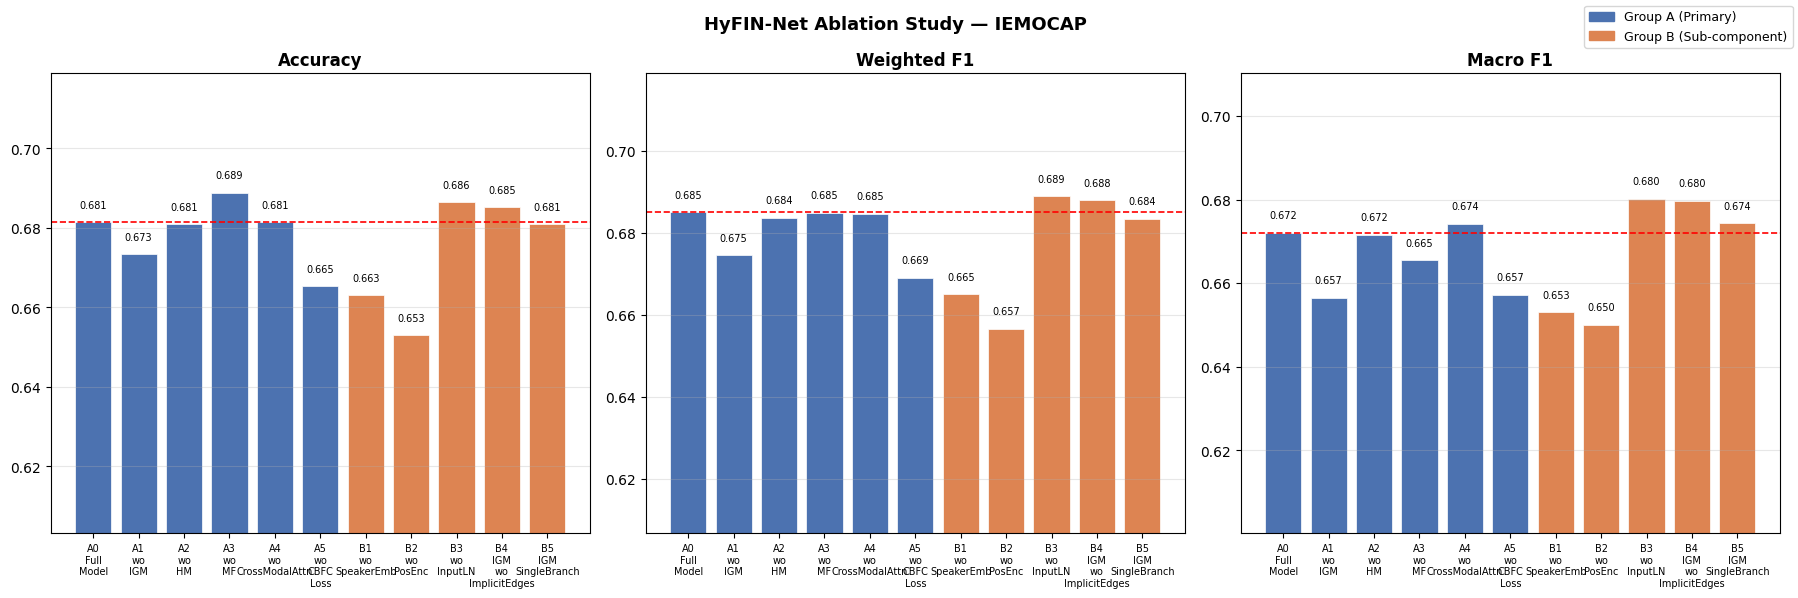

Saved ablation_grouped_bar.png


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = [('Acc', 'Accuracy'), ('wF1', 'Weighted F1'), ('mF1', 'Macro F1')]
colors_A = '#4C72B0'; colors_B = '#DD8452'

for ax, (col, label) in zip(axes, metrics):
    variants = df.index.tolist()
    values   = df[col].tolist()
    colors   = [colors_A if df.loc[v, 'Group'] == 'A' else colors_B for v in variants]
    bars = ax.bar(range(len(variants)), values, color=colors, edgecolor='white', linewidth=0.5)
    if baseline is not None:
        ax.axhline(baseline[col], color='red', linestyle='--', linewidth=1.2, label='Baseline')
    ax.set_xticks(range(len(variants)))
    ax.set_xticklabels([v.replace('_', '\n') for v in variants], fontsize=7, rotation=0)
    ax.set_title(label, fontweight='bold')
    ax.set_ylim(max(0, df[col].min() - 0.05), min(1.0, df[col].max() + 0.03))
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

patch_A = mpatches.Patch(color=colors_A, label='Group A (Primary)')
patch_B = mpatches.Patch(color=colors_B, label='Group B (Sub-component)')
fig.legend(handles=[patch_A, patch_B], loc='upper right', fontsize=9)
fig.suptitle('HyFIN-Net Ablation Study — IEMOCAP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'ablation_grouped_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ablation_grouped_bar.png')

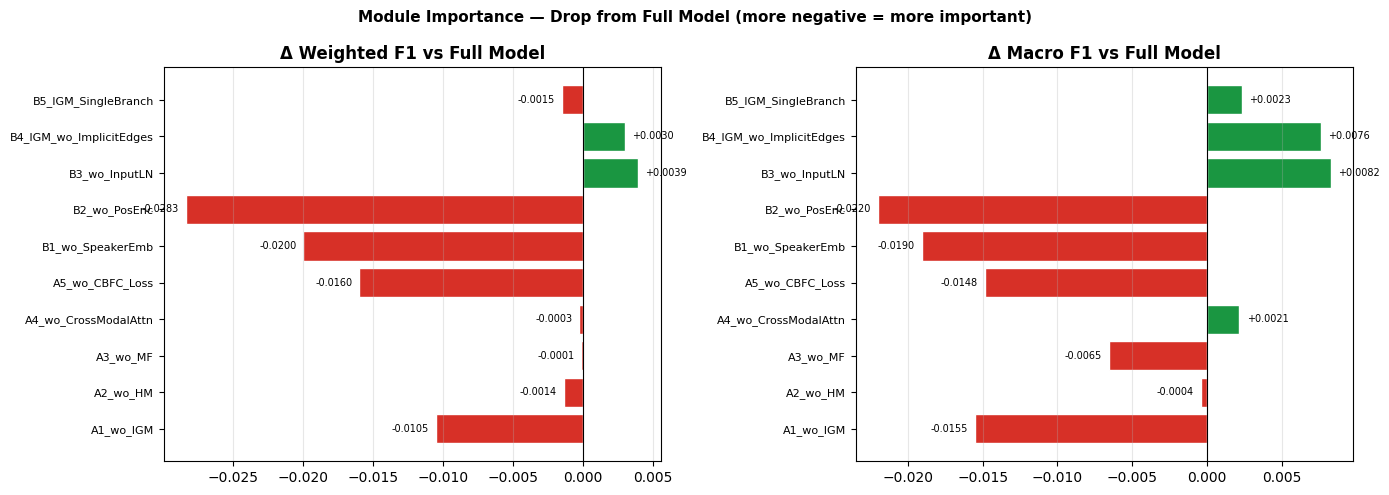

Saved ablation_delta_bar.png


In [18]:
if baseline is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    delta_cols = [('Δ_wF1', 'Δ Weighted F1 vs Full Model'), ('Δ_mF1', 'Δ Macro F1 vs Full Model')]
    for ax, (col, label) in zip(axes, delta_cols):
        # Exclude baseline itself
        sub = df[df.index != 'A0_Full_Model']
        variants = sub.index.tolist()
        deltas   = sub[col].tolist()
        colors   = ['#d73027' if d < 0 else '#1a9641' for d in deltas]
        ax.barh(range(len(variants)), deltas, color=colors, edgecolor='white')
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_yticks(range(len(variants)))
        ax.set_yticklabels(variants, fontsize=8)
        ax.set_title(label, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
        for i, (v, d) in enumerate(zip(variants, deltas)):
            ax.text(d + (0.0005 if d >= 0 else -0.0005), i,
                    f'{d:+.4f}', va='center', ha=('left' if d >= 0 else 'right'), fontsize=7)
    fig.suptitle('Module Importance — Drop from Full Model (more negative = more important)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'ablation_delta_bar.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved ablation_delta_bar.png')
else:
    print('Baseline not available — run A0_Full_Model first.')

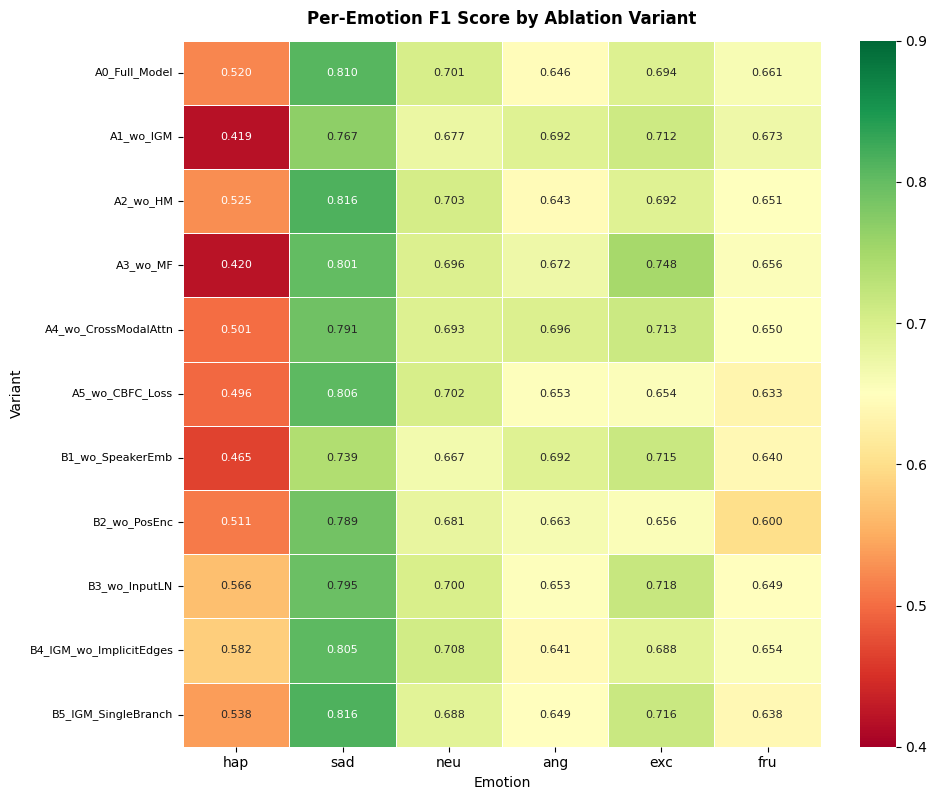

Saved ablation_per_emotion_heatmap.png


In [19]:
EMOTION_LABELS = {
    'iemocap': ['hap', 'sad', 'neu', 'ang', 'exc', 'fru'],
    'meld':    ['neutral', 'surprise', 'fear', 'sadness', 'joy', 'disgust', 'anger'],
}
emo_labels = EMOTION_LABELS.get(cfg.dataset, [str(i) for i in range(cfg.n_classes[cfg.dataset])])

heatmap_data = {}
for name, r in all_results.items():
    yt = np.array(r.get('y_true', []))
    yp = np.array(r.get('y_pred', []))
    if len(yt) == 0:
        continue
    per_class = f1_score(yt, yp, average=None, labels=list(range(len(emo_labels))))
    heatmap_data[name] = per_class

if heatmap_data:
    heat_df = pd.DataFrame(heatmap_data, index=emo_labels).T
    heat_df = heat_df.reindex([v for v in ABLATION_REGISTRY if v in heat_df.index])

    fig, ax = plt.subplots(figsize=(10, 0.6 * len(heat_df) + 1.5))
    sns.heatmap(heat_df, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0.4, vmax=0.9, ax=ax, linewidths=0.5, linecolor='white',
                annot_kws={'size': 8})
    ax.set_title('Per-Emotion F1 Score by Ablation Variant', fontweight='bold', pad=12)
    ax.set_xlabel('Emotion'); ax.set_ylabel('Variant')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'ablation_per_emotion_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved ablation_per_emotion_heatmap.png')
else:
    print('No y_true/y_pred available — run ablation loop first.')

In [20]:
for col, fname in [('Acc','ablation_accuracy_bar.png'),
                   ('wF1','ablation_wf1_bar.png'),
                   ('mF1','ablation_mf1_bar.png')]:
    fig, ax = plt.subplots(figsize=(12, 4))
    variants = df.index.tolist()
    values   = df[col].tolist()
    colors   = [colors_A if df.loc[v,'Group']=='A' else colors_B for v in variants]
    bars = ax.bar(range(len(variants)), values, color=colors, edgecolor='white')
    if baseline is not None:
        ax.axhline(baseline[col], color='red', ls='--', lw=1.2, label='Full Model')
    ax.set_xticks(range(len(variants)))
    ax.set_xticklabels([v.replace('_','\n') for v in variants], fontsize=7)
    ax.set_ylabel(col); ax.set_title(f'Ablation — {col}', fontweight='bold')
    ax.set_ylim(max(0, df[col].min()-0.05), min(1.0, df[col].max()+0.03))
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / fname, dpi=150, bbox_inches='tight')
    plt.close()
print('Individual metric bar charts saved.')

Individual metric bar charts saved.


## Interpretation Guide

| Symbol | Meaning |
|--------|---------|
| Δ wF1 < −0.01 | Module is **important** — removing it hurts notably |
| Δ wF1 ≈ 0 | Module is **redundant** or compensated by others |
| Δ wF1 > 0 | Removing module **helps** — consider redesign or removal |

**Group A** — Primary ablations test each graph processing block independently.
**Group B** — Sub-component ablations isolate encoder internals and IGM details.

Look at the delta bar chart (`ablation_delta_bar.png`): most negative bar = most important module.
Look at the per-emotion heatmap: reveals if a module helps specific emotion classes more than others.